## Classifying Descriptors in 311 Noise Data

This notebook classifies the descriptor column of noise data from 2016-2024 to a smaller set of categories. The goal is to reduce the number of unique descriptors to a manageable number for analysis.

Input: nyc_311_noise_{year}.csv files from 2016 to 2024.

Output: Modifies the input csv files to add a new column `descriptor_category` with the reclassified categories. The original `descriptor` column is retained for reference. 

### Load Data
Load the nyc_311_noise_{year}.csv files from 2016 to 2024 and concatenate them into a single DataFrame.

Assuming the data files are in a directory called noise_complaint_data.

```
noise_complaint_data/
├── nyc_311_noise_2016.csv
├── nyc_311_noise_2017.csv
├── nyc_311_noise_2018.csv
├── nyc_311_noise_2019.csv
├── nyc_311_noise_2020.csv
├── nyc_311_noise_2021.csv
├── nyc_311_noise_2022.csv
├── nyc_311_noise_2023.csv
└── nyc_311_noise_2024.csv
```

In [1]:
import pandas as pd
from pathlib import Path

data_dir = Path("noise_complaint_data")
years = range(2016, 2025)

dfs = []
for year in years:
    file_path = data_dir / f"nyc_311_noise_{year}.csv"
    if file_path.exists():
        dfs.append(pd.read_csv(file_path))

noise_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
noise_df.head()

,unique_key,created_date,closed_date,status,complaint_type,descriptor,incident_zip,latitude,longitude,location,descriptor_category
0,33436978,2016-05-25T18:31:00.000,2024-01-02T17:45:00.000,Closed,Noise,Noise: Construction Equipment (NC1),11208.0,40.688438,-73.869595,"\n, \n(40.68843836679542, -73.86959522983916)",Construction
1,33203168,2016-04-24T19:40:03.000,2016-04-24T21:12:40.000,Closed,Noise - Street/Sidewalk,Loud Music/Party,11368.0,40.752389,-73.843700,"\n, \n(40.75238928342247, -73.84369968736024)",Entertainment
2,33684651,2016-06-25T09:48:00.000,NaN,Open,Noise,Noise: Construction Equipment (NC1),11209.0,40.617945,-74.033311,"\n, \n(40.617944578969464, -74.03331146905523)",Construction
3,34326388,2016-09-15T20:35:42.000,2016-09-15T21:00:23.000,Closed,Noise - Street/Sidewalk,Loud Talking,11368.0,40.747989,-73.851838,"\n, \n(40.74798922265734, -73.85183760334836)",Talking
4,34543168,2016-10-15T08:53:00.000,NaN,Open,Noise,Noise: Construction Before/After Hours (NM1),10016.0,40.746629,-73.983774,"\n, \n(40.74662865682536, -73.9837740428889)",Construction


In [2]:
print(f"Number of rows: {len(noise_df)}")

Number of rows: 5500238


### Descriptor Statistics
Print all unique descriptors and their percentages in the dataset. This will help identify which descriptors are most common and which can be grouped together.

In [3]:
# Get unique descriptors and their counts  
descriptor_counts = noise_df['descriptor'].value_counts()
descriptor_percentages = noise_df['descriptor'].value_counts(normalize=True) * 100

print(f"Unique Descriptors: {len(descriptor_counts)}")
print(descriptor_percentages)

Unique Descriptors: 35
descriptor
Loud Music/Party                                                           56.999754
Banging/Pounding                                                           13.994654
Loud Talking                                                                8.005602
Car/Truck Music                                                             5.338080
Noise: Construction Before/After Hours (NM1)                                3.681606
Other                                                                       2.745737
Car/Truck Horn                                                              1.838939
Engine Idling                                                               1.540207
Noise: Construction Equipment (NC1)                                         1.245056
Noise, Barking Dog (NR5)                                                    1.110625
Loud Television                                                             0.799438
Noise: Alarms (NR3)            

Plot a pie chart of all descriptors.

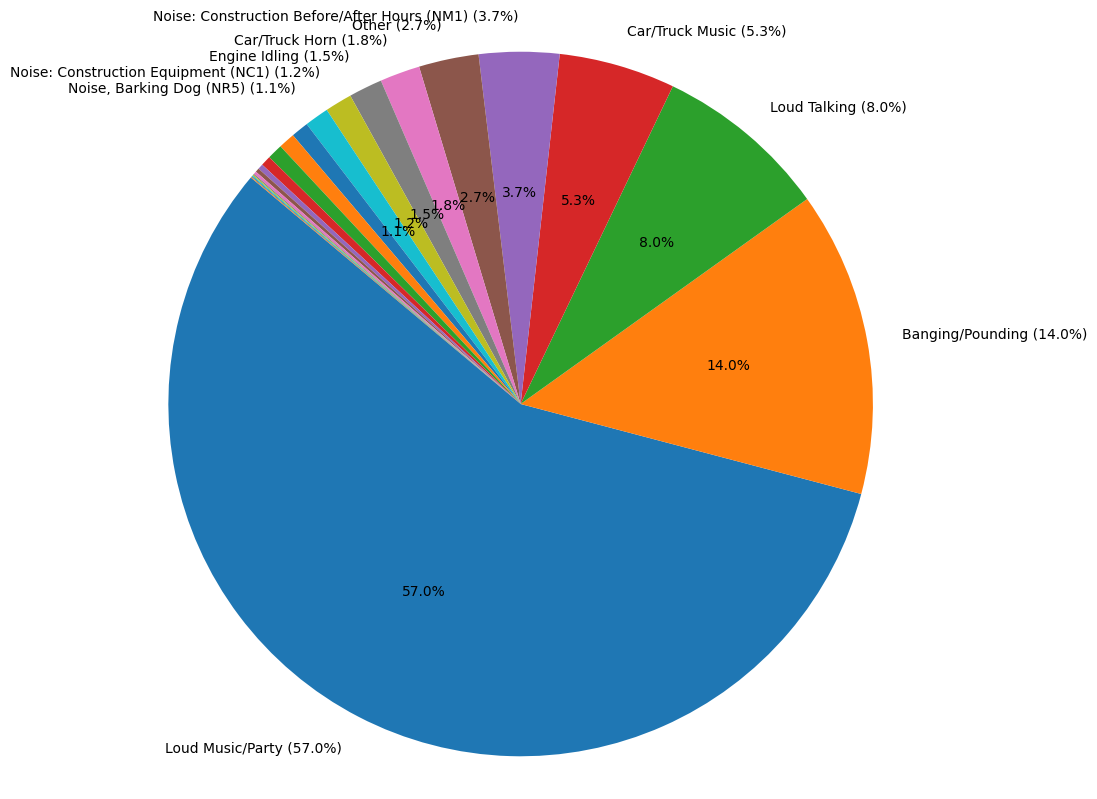

In [4]:
# plot a pie chart of all descriptors
# only label on pie chart if the percentage is greater than 1%
import matplotlib.pyplot as plt
labels = [f"{desc} ({perc:.1f}%)" if perc > 1 else "" for desc, perc in descriptor_percentages.items()]

def autopct_if_big(pct):
    threshold = 1.0 # Only show labels for slices greater than 1%
    return f"{pct:.1f}%" if pct >= threshold else ""

plt.figure(figsize=(10, 10))
plt.pie(descriptor_percentages, labels=labels, autopct=autopct_if_big, startangle=140)
plt.axis('equal')
plt.show()


### Reclassify Descriptors
Classify the descriptors into the following categories:
- Entertainment
    - Loud Music/Party
    - Loud Television
    - Noise: Loud Music/Nighttime(Mark Date And Time) (NP1)
    - Noise: Loud Music/Daytime (Mark Date And Time) (NN1)
    - Noise: Loud Music From Siebel System - For Dep Internal Use Only (NP21)
- Talking
    - Loud Talking
    - News Gathering
- Banging/Pounding
    - Banging/Pounding
- Engine
    - Engine Idling
    - Noise: Alarms (NR3)
    - Noise: air condition/ventilation equipment (NV1)
    - Noise:  lawn care equipment (NCL)
    - Noise: Manufacturing Noise (NK1)
- Construction
    - Noise: Construction Before/After Hours (NM1)
    - Noise: Construction Equipment (NC1)
    - Noise: Jack Hammering (NC2)
- Vehicle
    - Car/Truck Music
    - Car/Truck Horn
    - Noise, Ice Cream Truck (NR4)
    - Noise: Private Carting Noise (NQ1)
    - Noise: Boat(Engine,Music,Etc) (NR10)
    - Noise: Boat(Engine
    - Noise: Vehicle (NR2)
    - Double Parked Blocking Vehicle
- Animal
    - Noise, Barking Dog (NR5)
    - Noise, Other Animals (NR6)
- Other
    - Other
    - NYPD
    - Noise: Other Noise Sources (Use Comments) (NZZ)
    - Noise
    - Partial Access
    - In Public
    - Other (complaint details)
    - No Access
    - Use Outside


Load data for each year separately and reclassify descriptors. A new column called `descriptor_category` will be created to store the new categories. The original descriptor column will be retained for reference.

In [5]:
# load data for each year separately
noise_dfs = {}
for year in years:
    file_path = data_dir / f"nyc_311_noise_{year}.csv"
    if file_path.exists():
        noise_dfs[year] = pd.read_csv(file_path)

In [6]:
# reclassify descriptors for each year
category_map = {
    # Entertainment
    "Loud Music/Party": "Entertainment",
    "Loud Television": "Entertainment",
    "Noise: Loud Music/Nighttime(Mark Date And Time) (NP1)": "Entertainment",
    "Noise: Loud Music/Daytime (Mark Date And Time) (NN1)": "Entertainment",
    "Noise: Loud Music From Siebel System - For Dep Internal Use Only (NP21)": "Entertainment",
    # Talking
    "Loud Talking": "Talking",
    "News Gathering": "Talking",
    # Banging/Pounding
    "Banging/Pounding": "Banging/Pounding",
    # Engine
    "Engine Idling": "Engine",
    "Noise: Alarms (NR3)": "Engine",
    "Noise: air condition/ventilation equipment (NV1)": "Engine",
    "Noise:  lawn care equipment (NCL)": "Engine",
    "Noise: Manufacturing Noise (NK1)": "Engine",
    # Construction
    "Noise: Construction Before/After Hours (NM1)": "Construction",
    "Noise: Construction Equipment (NC1)": "Construction",
    "Noise: Jack Hammering (NC2)": "Construction",
    # Vehicle
    "Car/Truck Music": "Vehicle",
    "Car/Truck Horn": "Vehicle",
    "Noise, Ice Cream Truck (NR4)": "Vehicle",
    "Noise: Private Carting Noise (NQ1)": "Vehicle",
    "Noise: Boat(Engine,Music,Etc) (NR10)": "Vehicle",
    "Noise: Boat(Engine": "Vehicle",
    "Noise: Vehicle (NR2)": "Vehicle",
    "Double Parked Blocking Vehicle": "Vehicle",
    # Animal
    "Noise, Barking Dog (NR5)": "Animal",
    "Noise, Other Animals (NR6)": "Animal",
    # Other
    "Other": "Other",
    "NYPD": "Other",
    "Noise: Other Noise Sources (Use Comments) (NZZ)": "Other",
    "Noise": "Other",
    "Partial Access": "Other",
    "In Public": "Other",
    "Other (complaint details)": "Other",
    "No Access": "Other",
    "Use Outside": "Other",
}

for year, df in noise_dfs.items():
    df["descriptor_category"] = df["descriptor"].map(category_map).fillna("Other")

Save the reclassified data back to csv files. Overwrites the original files

In [7]:
# Save the reclassified data back to csv files
# This will overwrite the original files
for year, df in noise_dfs.items():
    output_path = data_dir / f"nyc_311_noise_{year}.csv"
    df.to_csv(output_path, index=False)


### Reclassified descriptor statistics

In [8]:
# reclassify descriptors for the combined dataframe from 2016 to 2024
noise_df["descriptor_category"] = noise_df["descriptor"].map(category_map).fillna("Other")

# Get unique descriptors and their counts  
descriptor_counts = noise_df['descriptor_category'].value_counts()
descriptor_percentages = noise_df['descriptor_category'].value_counts(normalize=True) * 100

print(f"Unique Descriptors: {len(descriptor_counts)}")
print(descriptor_percentages)

Unique Descriptors: 8
descriptor_category
Entertainment       57.801153
Banging/Pounding    13.994649
Talking              8.050215
Vehicle              7.645851
Construction         5.391494
Engine               3.165881
Other                2.802933
Animal               1.147823
Name: proportion, dtype: float64


Pie chart for reclassified descriptors.

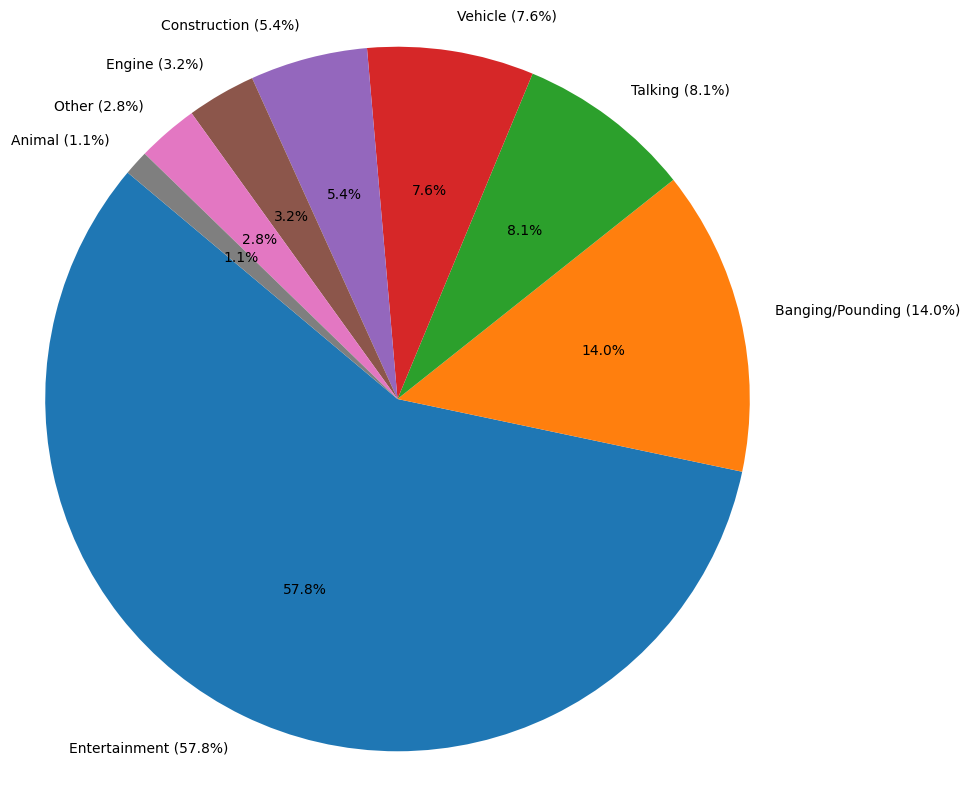

In [9]:
# plot a pie chart of all descriptors
# only label on pie chart if the percentage is greater than 1%
import matplotlib.pyplot as plt
labels = [f"{desc} ({perc:.1f}%)" if perc > 1 else "" for desc, perc in descriptor_percentages.items()]

def autopct_if_big(pct):
    threshold = 1.0 # Only show labels for slices greater than 1%
    return f"{pct:.1f}%" if pct >= threshold else ""

plt.figure(figsize=(10, 10))
plt.pie(descriptor_percentages, labels=labels, autopct=autopct_if_big, startangle=140)
plt.axis('equal')
plt.show()

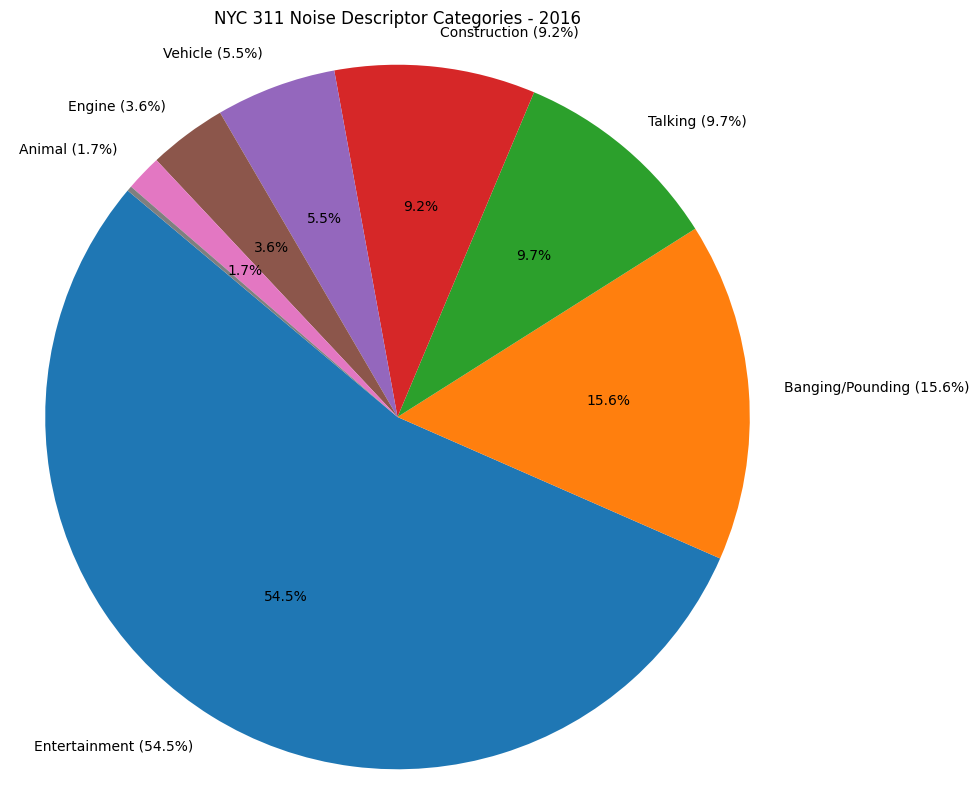

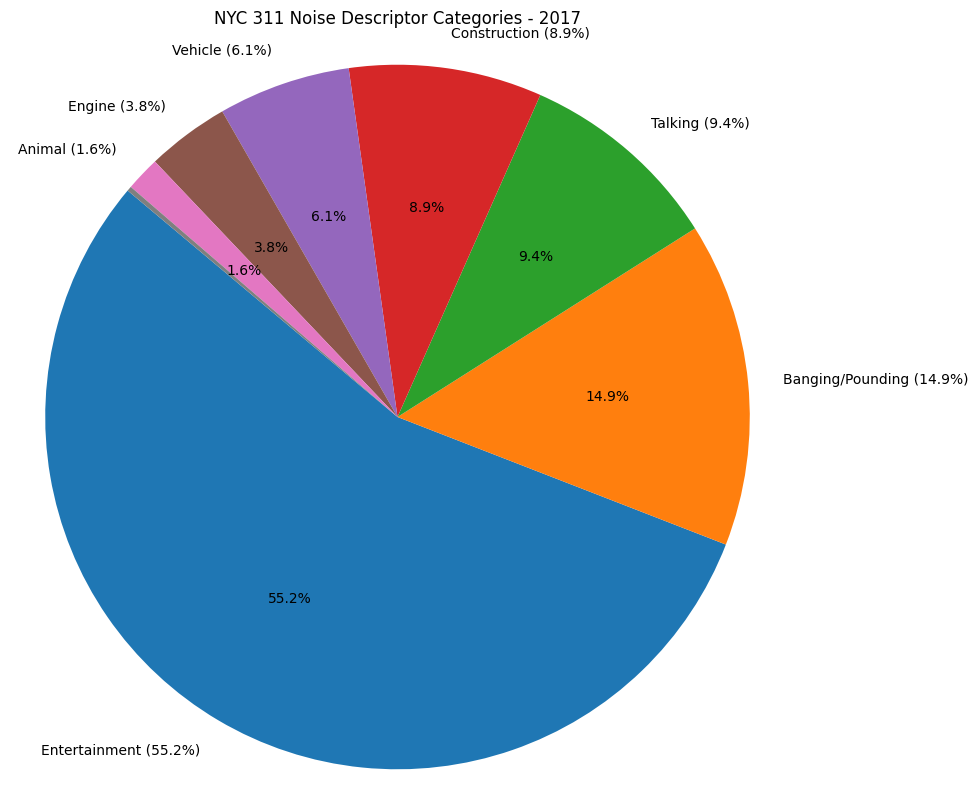

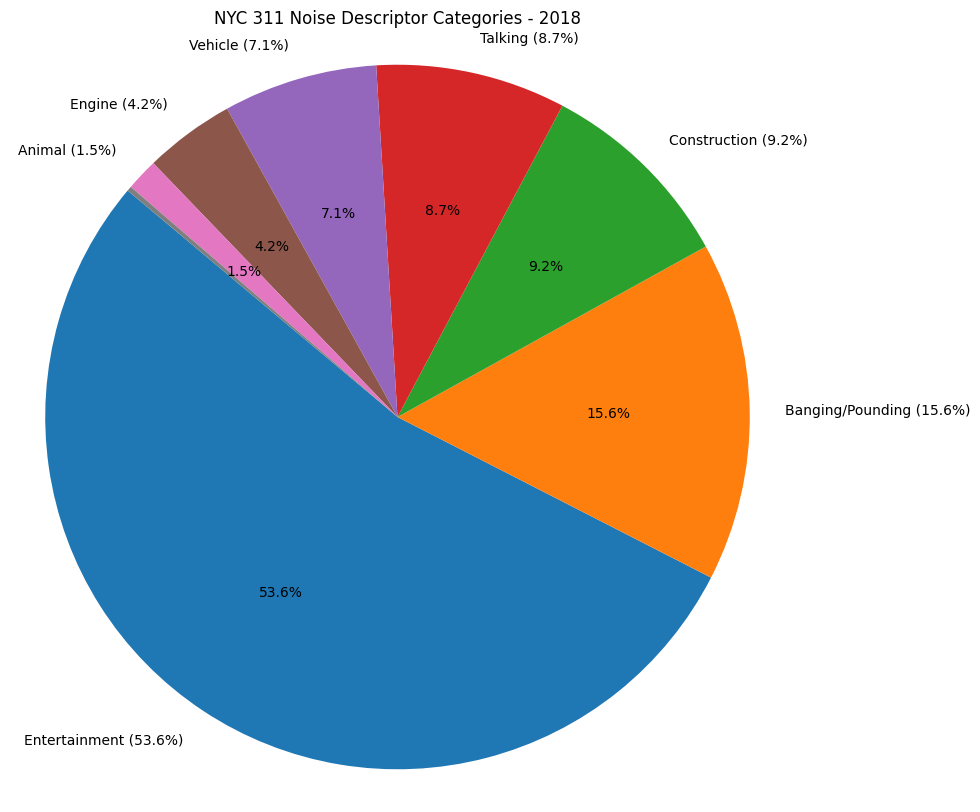

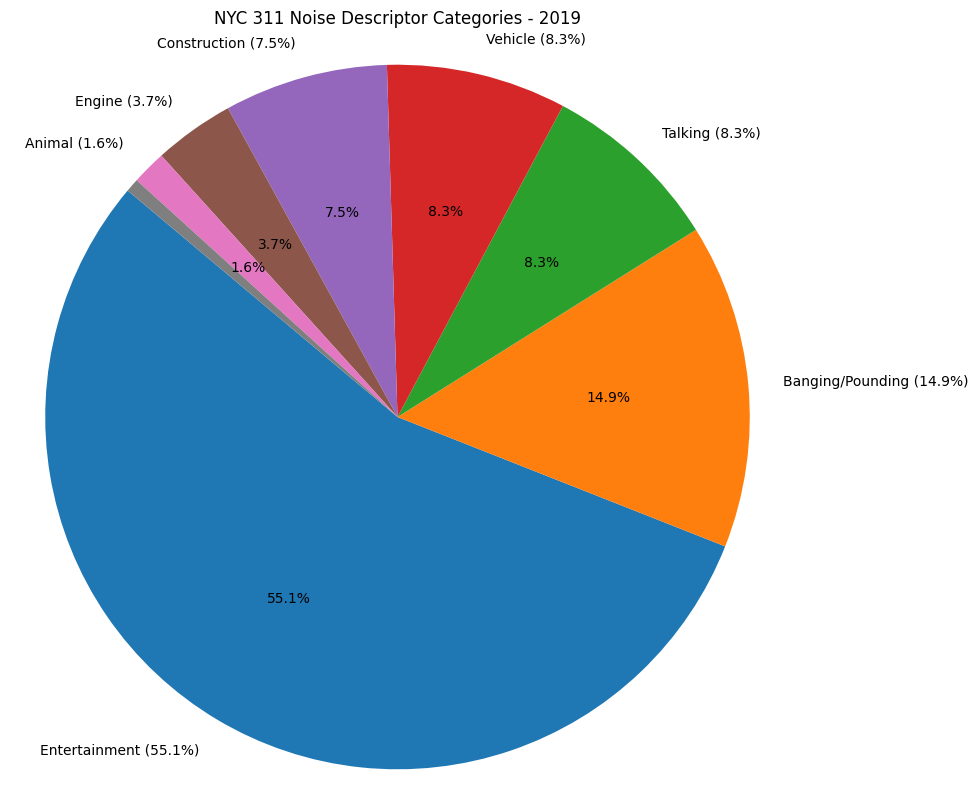

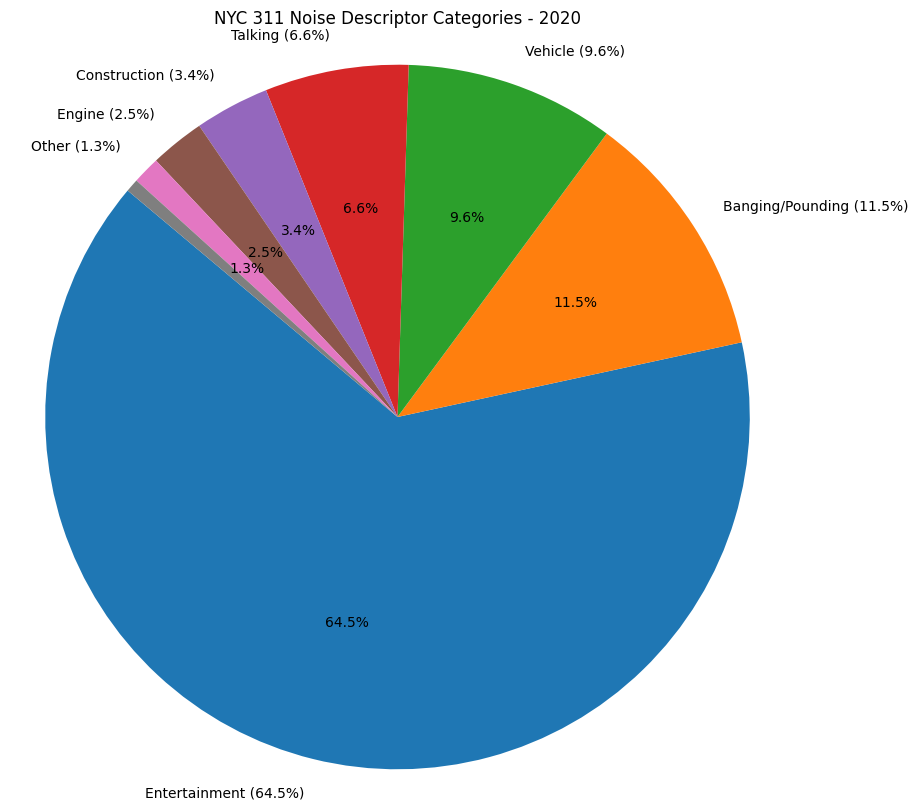

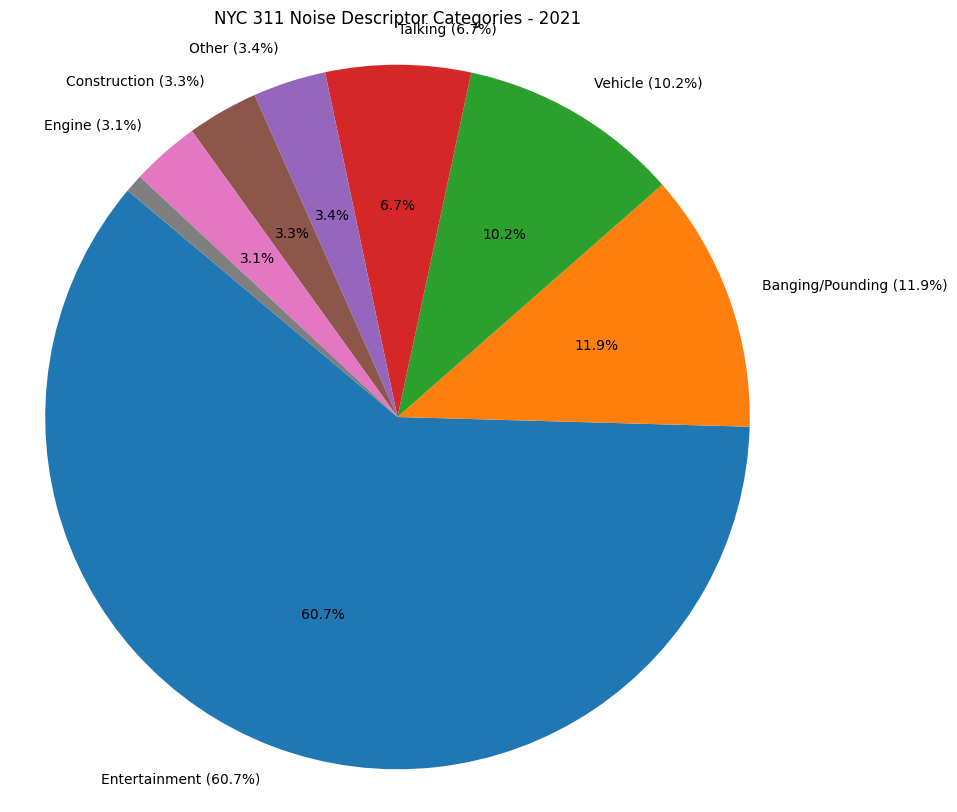

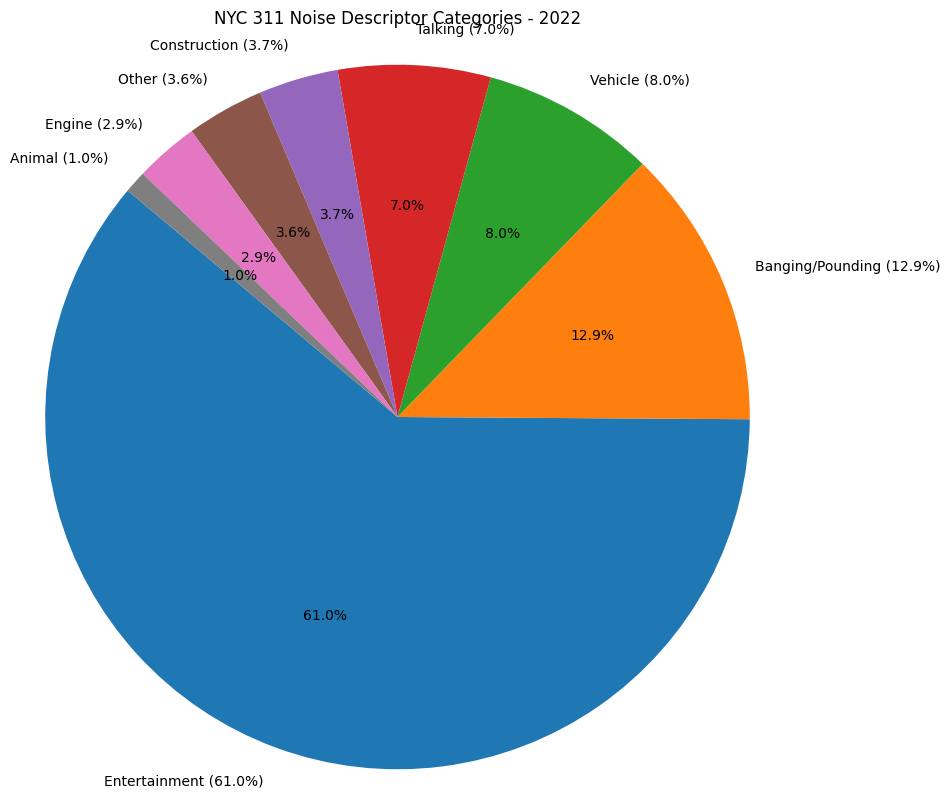

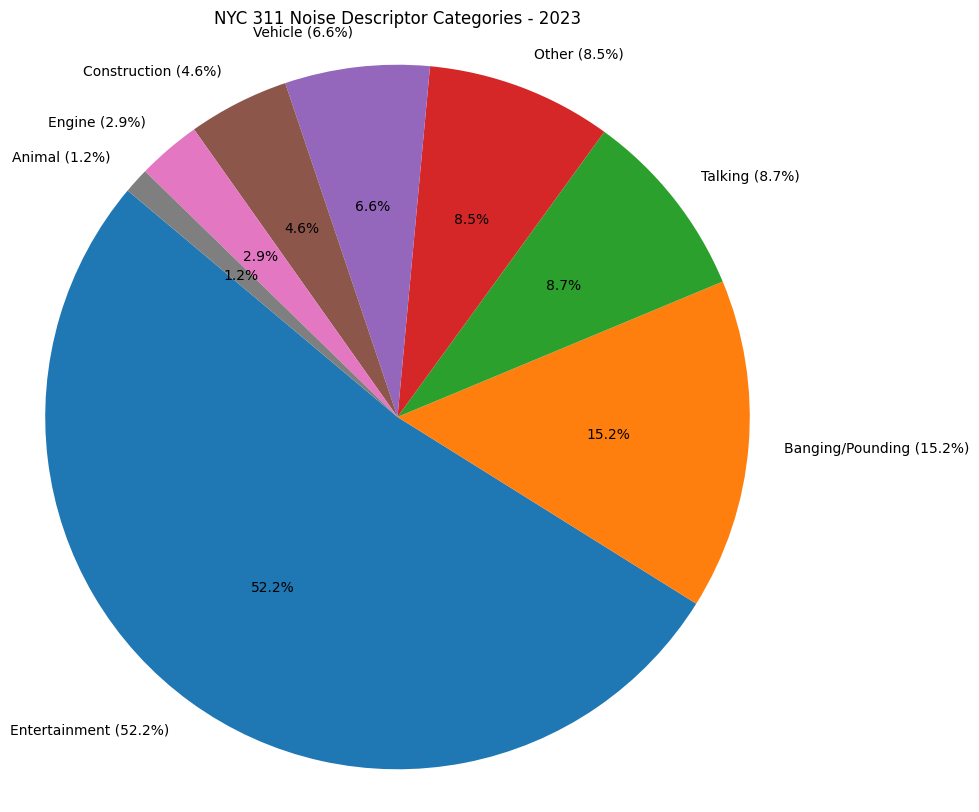

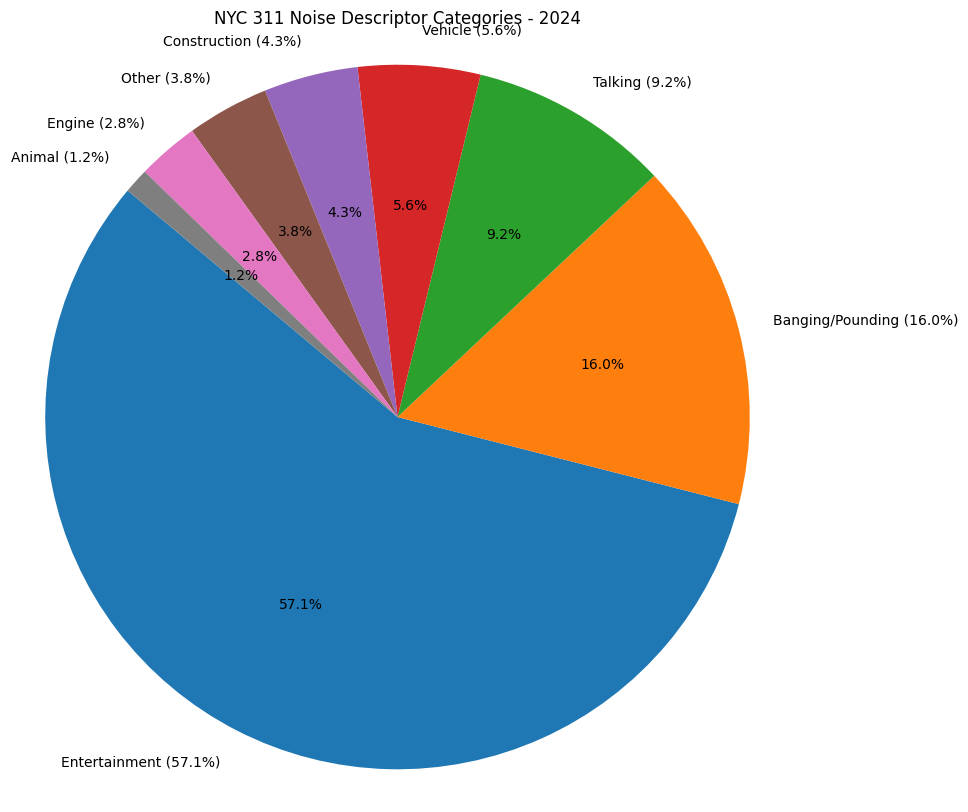

In [10]:
# plot a pie chart of descriptors for each year (2016-2024)
# only label on pie chart if the percentage is greater than 1%

import matplotlib.pyplot as plt

def autopct_if_big(pct, threshold=1.0):
    # Only show labels for slices >= threshold (%)
    return f"{pct:.1f}%" if pct >= threshold else ""

# Optional: save plots to a folder (recommended)
plots_dir = data_dir / "descriptor_pies_by_year"
plots_dir.mkdir(parents=True, exist_ok=True)

for year, df in noise_dfs.items():
    # compute percentages for this year
    yearly_percentages = df["descriptor_category"].value_counts(normalize=True) * 100

    # build labels (only show text if > 1%)
    labels = [
        f"{cat} ({perc:.1f}%)" if perc > 1 else ""
        for cat, perc in yearly_percentages.items()
    ]

    # plot
    plt.figure(figsize=(10, 10))
    plt.pie(
        yearly_percentages,
        labels=labels,
        autopct=lambda pct: autopct_if_big(pct, threshold=1.0),
        startangle=140
    )
    plt.axis("equal")
    plt.title(f"NYC 311 Noise Descriptor Categories - {year}")

    # save and show (you can comment out plt.show() if too many pop-ups)
    output_path = plots_dir / f"descriptor_category_pie_{year}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    plt.close()


In [11]:
# compute yearly percentage distribution for each descriptor category

import pandas as pd

years_sorted = sorted(noise_dfs.keys())
categories = sorted(noise_df["descriptor_category"].unique())

yearly_category_percentages = pd.DataFrame(
    index=years_sorted,
    columns=categories
)

for year, df in noise_dfs.items():
    percentages = df["descriptor_category"].value_counts(normalize=True) * 100
    yearly_category_percentages.loc[year] = percentages

# fill missing values with 0 (in case a category does not appear in a year)
yearly_category_percentages = yearly_category_percentages.fillna(0)

yearly_category_percentages.head()


C:\Users\Frede\AppData\Local\Temp\ipykernel_40248\3065779809.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  yearly_category_percentages = yearly_category_percentages.fillna(0)


,Animal,Banging/Pounding,Construction,Engine,Entertainment,Other,Talking,Vehicle
2016,1.659949,15.551442,9.209924,3.593479,54.533989,0.232820,9.690429,5.527968
2017,1.581068,14.888219,8.859512,3.801400,55.213879,0.218862,9.364716,6.072344
2018,1.477241,15.573746,9.208057,4.154194,53.576508,0.219174,8.717098,7.073984
2019,1.576942,14.900953,7.513177,3.700678,55.125909,0.619361,8.305042,8.257938
2020,0.601531,11.475034,3.424909,2.506776,64.512797,1.265406,6.597062,9.616485


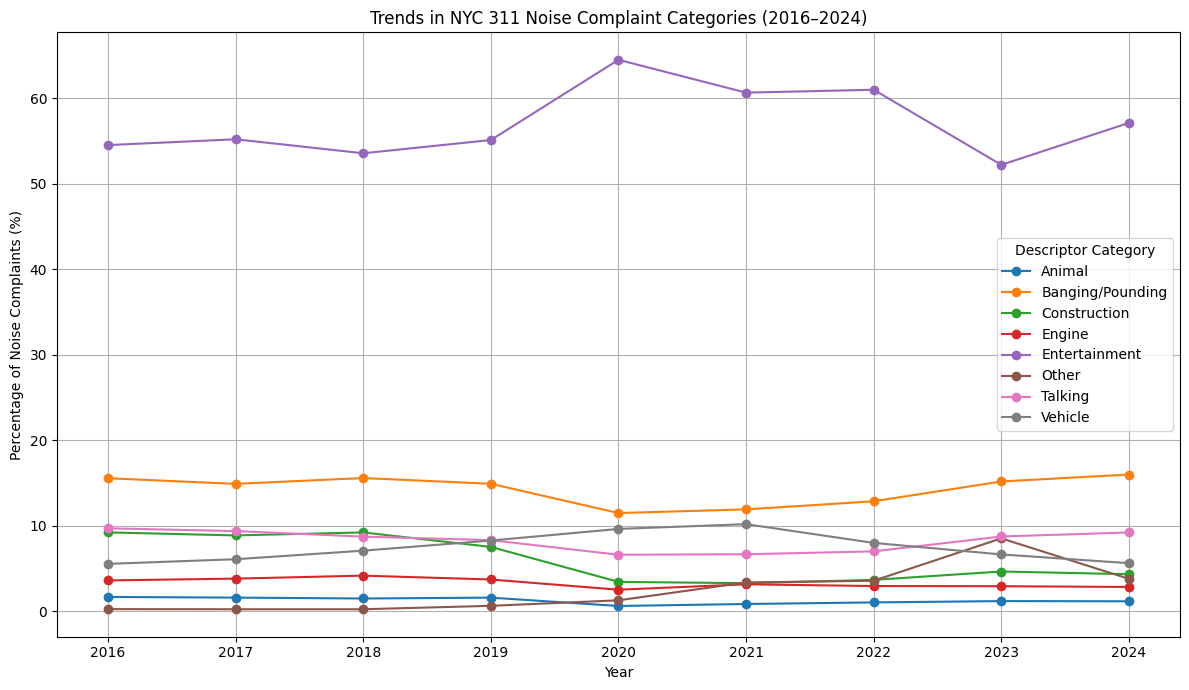

In [13]:
# plot line chart of descriptor category percentages from 2016 to 2024
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for category in yearly_category_percentages.columns:
    plt.plot(
        yearly_category_percentages.index,
        yearly_category_percentages[category],
        marker="o",
        label=category
    )

plt.xlabel("Year")
plt.ylabel("Percentage of Noise Complaints (%)")
plt.title("Trends in NYC 311 Noise Complaint Categories (2016–2024)")
plt.legend(title="Descriptor Category")
plt.grid(True)
plt.tight_layout()
plt.show()


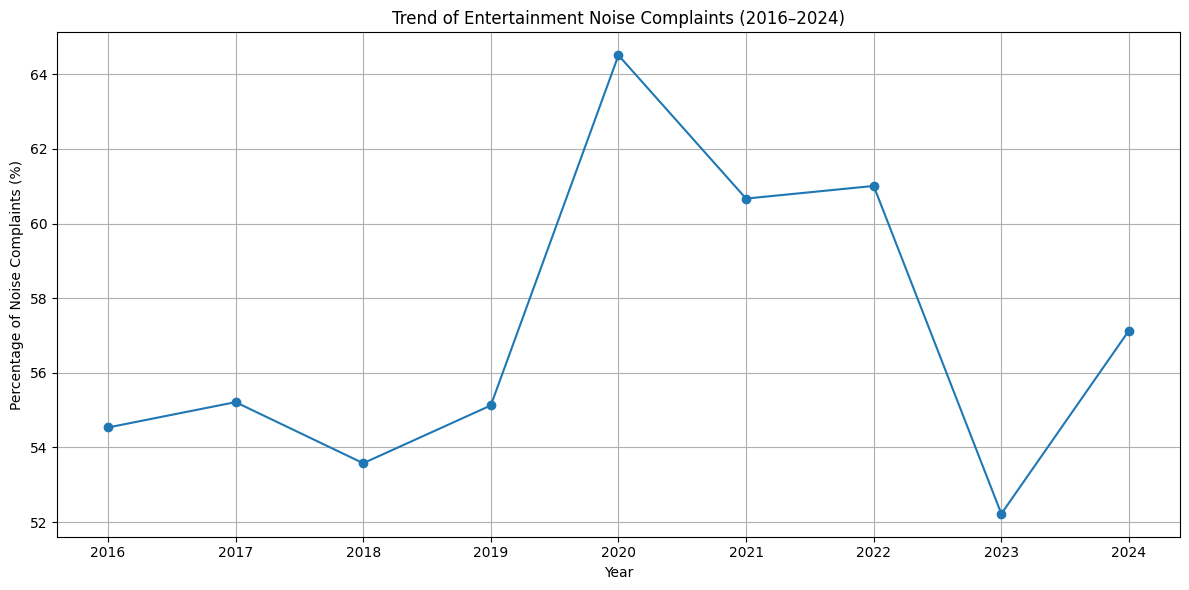

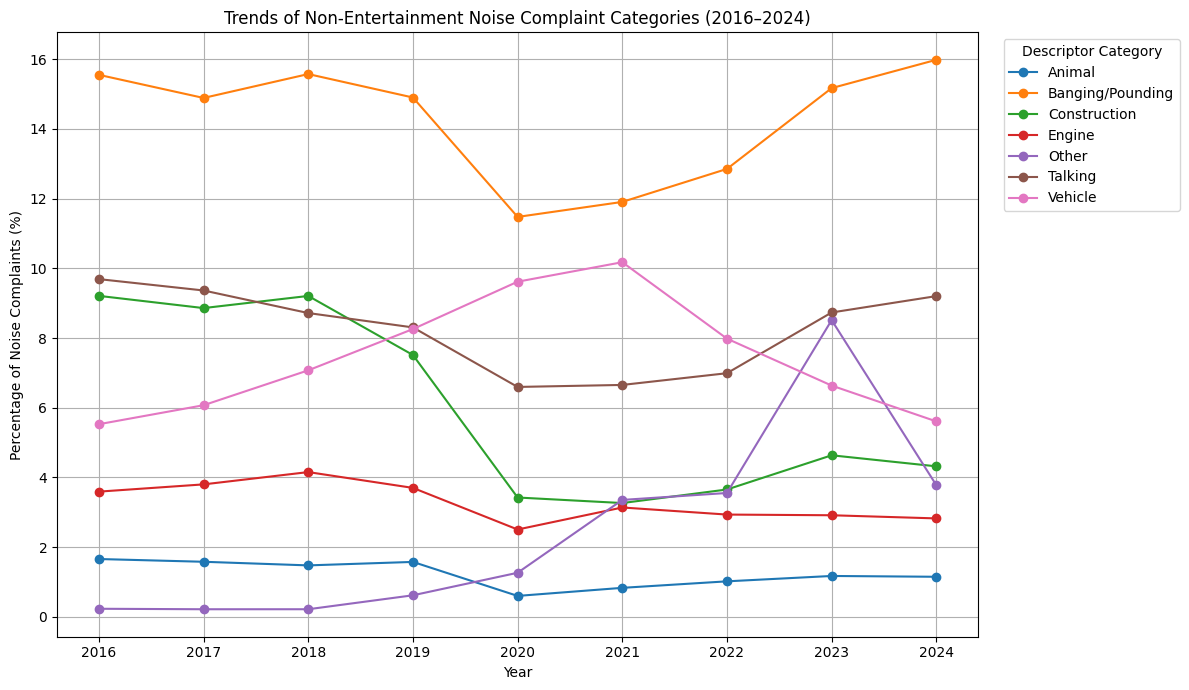

In [16]:
# plot line charts of descriptor category percentages from 2016 to 2024
# separate Entertainment from other categories for better visualization

years_sorted = yearly_category_percentages.index

# plot Entertainment only
if "Entertainment" in yearly_category_percentages.columns:
    plt.figure(figsize=(12, 6))
    plt.plot(
        years_sorted,
        yearly_category_percentages["Entertainment"],
        marker="o",
        label="Entertainment"
    )
    plt.xlabel("Year")
    plt.ylabel("Percentage of Noise Complaints (%)")
    plt.title("Trend of Entertainment Noise Complaints (2016–2024)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# plot all other categories except Entertainment
other_categories = [c for c in yearly_category_percentages.columns if c != "Entertainment"]

plt.figure(figsize=(12, 7))

for category in other_categories:
    plt.plot(
        years_sorted,
        yearly_category_percentages[category],
        marker="o",
        label=category
    )

plt.xlabel("Year")
plt.ylabel("Percentage of Noise Complaints (%)")
plt.title("Trends of Non-Entertainment Noise Complaint Categories (2016–2024)")
plt.legend(
    title="Descriptor Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(True)
plt.tight_layout()
plt.show()

